In [19]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/mvtec-ad-dataset/mvtec_anomaly_detection.tar.xz
/kaggle/input/notebooks/chrysoulatsitsifa/thesis-notebook-2/__results__.html
/kaggle/input/notebooks/chrysoulatsitsifa/thesis-notebook-2/readme.txt
/kaggle/input/notebooks/chrysoulatsitsifa/thesis-notebook-2/license.txt
/kaggle/input/notebooks/chrysoulatsitsifa/thesis-notebook-2/best_model_optimized.h5
/kaggle/input/notebooks/chrysoulatsitsifa/thesis-notebook-2/__notebook__.ipynb
/kaggle/input/notebooks/chrysoulatsitsifa/thesis-notebook-2/__output__.json
/kaggle/input/notebooks/chrysoulatsitsifa/thesis-notebook-2/custom.css
/kaggle/input/notebooks/chrysoulatsitsifa/thesis-notebook-2/wood/readme.txt
/kaggle/input/notebooks/chrysoulatsitsifa/thesis-notebook-2/wood/license.txt
/kaggle/input/notebooks/chrysoulatsitsifa/thesis-notebook-2/wood/ground_truth/hole/000_mask.png
/kaggle/input/notebooks/chrysoulatsitsifa/thesis-notebook-2/wood/ground_truth/hole/003_mask.png
/kaggle/input/notebooks/chrysoulatsitsifa/thesis-notebook-2/woo

# 🎓 THESIS PROJECT: VISUAL ANOMALY DETECTION
## NOTEBOOK 3: DATA AUGMENTATION QUALITY CONTROL (SSIM)

**OBJECTIVE:**
This notebook conducts a **Scientific Feasibility Study** regarding Data Augmentation. Before introducing synthetic distortions (such as noise or lighting variations) into the training pipeline, it is imperative to mathematically verify that these modifications do not compromise the **structural integrity** of the input data. This step acts as a "Safety Gate" between raw data and model training.

**METHODOLOGY:**
1.  **Synthetic Degradation:** Controlled application of specific defects:
    * **Gaussian Noise:** Simulating sensor grain.
    * **Luminance Shifts:** Simulating environmental lighting changes.
2.  **Structural Analysis:** Utilization of the **Structural Similarity Index (SSIM)** metric (from `scikit-image`) to quantify degradation on a normalized scale (0.0 to 1.0), rather than relying on subjective visual inspection.
3.  **Visualization:** Generation of **Difference Heatmaps** to spatially pinpoint structural loss.
4.  **Sensitivity Analysis:** Execution of an iterative **"Stress Test"** (Multi-value loop) to determine the exact "Breaking Point" where the image becomes unrecognizable.

**EXPECTED OUTCOME:**
* A scientifically derived **"Safety Threshold"** for augmentation parameters.
* A consolidated **CSV Report** documenting the sensitivity curves.
* **Final Decision:** Confirmation that the chosen parameters are safe to be used for Transfer Learning in **Notebook 4**.

### BLOCK 1 : LIBRARY IMPORTS & ENVIRONMENT CONFIGURATION

**OBJECTIVE:**
This block initializes the Python environment by importing the necessary libraries for data manipulation, image processing, visualization, and result exporting.

**KEY LIBRARIES:**
* **NumPy (`np`):** Used for high-performance numerical operations and handling images as matrices.
* **Pandas (`pd`):** Essential for structuring experimental results into DataFrames and exporting them to `.csv` format for the thesis documentation.
* **OpenCV (`cv2`):** The primary tool for image reading, resizing, and color conversion.
* **Matplotlib (`plt`):** Used for rendering images, plotting heatmaps, and generating degradation graphs.
* **SSIM (`structural_similarity`):** A specific metric from `scikit-image` used to quantify the degradation of image quality (the core objective of this notebook).
* **Tarfile:** Essential for extracting the compressed dataset (`.tar.xz`) programmatically.

**CONFIGURATION:**
We also set global visualization parameters (figure size and colormap) to ensure consistent and clear output for all subsequent plots.

### BLOCK 1: LIBRARY IMPORTS & ENVIRONMENT CONFIGURATION

**OBJECTIVE:**
This block establishes the computational environment specifically designed for **Image Quality Control (QA)**. Unlike previous notebooks that focused on Deep Learning, this module prioritizes mathematical signal processing tools to assess structural integrity before training.

**KEY LIBRARIES & DEPENDENCIES:**
* **Scientific Computing (`numpy`, `pandas`):** Used for matrix operations and for structuring the Sensitivity Analysis results into a DataFrame for final reporting (`.csv` export).
* **Image Processing (`cv2`, `skimage`):**
    * **OpenCV:** Handles efficient image loading, grayscale conversion, and resizing.
    * **SSIM (Structural Similarity Index):** The core metric imported from `scikit-image`. It replaces standard accuracy metrics, allowing us to quantify visual degradation on a scale from 0.0 to 1.0.
* **Visualization (`matplotlib`):** Configured to render high-contrast comparison grids (Original vs. Augmented) and heatmaps that visualize structural loss.
* **System Operations (`os`, `tarfile`):** Essential for programmatic dataset extraction and file path management within the Kaggle environment.

**STRATEGIC DISTINCTION:**
* **No TensorFlow/PyTorch:** Deliberately excluded to maintain a lightweight execution environment. This notebook focuses purely on input data validation, not neural network training.

**GLOBAL CONFIGURATION:**
* **`IMG_SIZE = (128, 128)`:** Standardizes input dimensions to match the architecture of the Autoencoder used in Notebooks 1 & 2.
* **`TARGET_CLASS = 'bottle'`:** Defines the specific subset of the MVTEC-AD dataset under examination.

In [20]:
# ==========================================================================================================================================================
# BLOCK 1: LIBRARY IMPORTS & ENVIRONMENT CONFIGURATION
# ==========================================================================================================================================================
# Description: Imports dependencies for Image Quality Control (SSIM/MSE), sets plotting
# styles, and defines global image parameters
# ==========================================================================================================================================================

print("INITIALIZING SYSTEM ENVIRONMENT & LOADING LIBRARIES...\n")
print("Action: Setting up Image Quality Metrics (SSIM/MSE) & Visualization tools.")
print()


# DATA MANIPULATION & VISUALIZATION
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# STANDARD SYSTEM LIBRARIES
import os
import tarfile


# IMAGE PROCESSING & METRICS LIBRARIES
# NOTE: Unlike NB1/NB2 we do not need TensorFlow here. We use OpenCV and Scikit-Image
# to mathematically analyze image structure (SSIM) before training
import cv2
from skimage.metrics import structural_similarity as ssim


# VISUALIZATION CONFIGURATION
# Set default figure size to (14, 8) for better visibility of noise details
plt.rcParams['figure.figsize'] = (14, 8)

# Set default colormap to 'gray' (essential for accurate SSIM visualization)
plt.rcParams['image.cmap'] = 'gray'


# GLOBAL PARAMETERS
# Define the global parameters for our images and the specific object we want to analyze
# IMG_SIZE: Resizing images to 128x128 for computational efficiency
# TARGET_CLASS: The specific category we are analyzing (e.g., 'bottle')
IMG_SIZE = (128, 128)
TARGET_CLASS = 'bottle'


# FINAL VERIFICATION
print("\n✅ BLOCK 1 COMPLETED: Libraries Loaded & Environment Configured.")

INITIALIZING SYSTEM ENVIRONMENT & LOADING LIBRARIES...

Action: Setting up Image Quality Metrics (SSIM/MSE) & Visualization tools.


✅ BLOCK 1 COMPLETED: Libraries Loaded & Environment Configured.


### BLOCK 2: DATA EXTRACTION & SETUP

**OBJECTIVE:**
This block manages the **Data Staging** phase. Since the MVTec AD dataset is hosted in a generic "Read-Only" input directory within Kaggle, it is strictly necessary to extract and migrate the data into the temporary "Writeable" working directory (`/kaggle/working/`) to perform image processing operations.

**OPERATIONAL LOGIC:**
The extraction process implements a robust, three-step logic to ensure efficiency and data integrity:

1.  **Path Configuration:** Defines source (archive) and destination (working) paths to establish a bridge between static storage and dynamic processing space.
2.  **Resource Optimization (Conditional Extraction):**
    * The code first checks if the data has already been extracted (`os.path.exists`).
    * **Benefit:** This prevents redundant unzipping operations, significantly reducing runtime during repeated experiments.
3.  **Double Integrity Verification:**
    * **Visual Check:** Prints the directory contents to provide immediate feedback to the researcher.
    * **Logical Check:** Programmatically asserts the existence of the specific `TARGET_CLASS` folder. This acts as a "Gatekeeper," ensuring the notebook only proceeds if the data is 100% ready.

In [21]:
# ==========================================================================================================================================================
# BLOCK 2: DATA EXTRACTION & SETUP
# ==========================================================================================================================================================
# Description: Handles the extraction of the dataset from the read-only input directory
# to the writeable working directory to enable image processing
# ==========================================================================================================================================================

# CONFIGURATION: PATHS SETUP
# dataset_path: The absolute path to the compressed dataset (Read-Only)
dataset_path = '/kaggle/input/mvtec-ad-dataset/mvtec_anomaly_detection.tar.xz'

# working_dir: The directory where we have write permissions
working_dir = '/kaggle/working/mvtec_anomaly_detection'


# EXECUTION: EXTRACTION LOGIC
# Optimization: Check if the folder exists to avoid re-extracting every time we run the notebook
if not os.path.exists(working_dir) and not os.path.exists(f'/kaggle/working/{TARGET_CLASS}'):
    print("Extracting dataset... Please wait.\n")
    # Open and extract the tar file
    with tarfile.open(dataset_path, 'r:*') as tar:
        tar.extractall('/kaggle/working/')
    print("Dataset extracted successfully\n.")
else:
    # If data exists skip extraction to save time
    print("Dataset is already extracted. Moving on\n.")


# FINAL VERIFICATION
# 1. Visual Check: Print contents of the working directory
print(f"Working Directory Contents: {os.listdir('/kaggle/working/')}\n")

# 2. Logic Check: Verify specifically that the target class folder exists
if os.path.exists(f'/kaggle/working/{TARGET_CLASS}'):
     print(f"✅ BLOCK 2 COMPLETED: Success! Class '{TARGET_CLASS}' is ready.")
else:
     print(f"BLOCK 2 ERROR: Class '{TARGET_CLASS}' failed to extract.")

Dataset is already extracted. Moving on
.
Working Directory Contents: ['.virtual_documents', 'cable', 'hazelnut', 'readme.txt', 'license.txt', 'carpet', 'toothbrush', 'ssim_sensitivity_results.csv', 'metal_nut', 'screw', 'grid', 'transistor', 'bottle', 'pill', 'wood', 'tile', 'zipper', 'leather', 'golden_reference.npy', 'capsule']

✅ BLOCK 2 COMPLETED: Success! Class 'bottle' is ready.


### BLOCK 3: LOAD REFERENCE IMAGE (SINGLE SAMPLE)

**OBJECTIVE:**
This block isolates and prepares a single **"Ground Truth"** reference image from the 'good' (non-anomalous) category. This specific sample will serve as the pristine baseline against which all synthetic degradations (noise, darkness) will be mathematically compared using the SSIM metric.

**PREPROCESSING PIPELINE (The `load_image` Function):**
We define a modular helper function to ensure consistent data handling. It executes three critical operations:

1.  **Defensive Loading (Robustness):**
    * Implements a safety check (`os.path.exists`) to prevent runtime crashes. If a file is missing, it fails gracefully by returning a blank (black) image, ensuring the experiment flow is not interrupted.
2.  **Grayscale Conversion (`cv2.IMREAD_GRAYSCALE`):**
    * Converts the image to a single channel (Luminance).
    * **Scientific Rationale:** SSIM is designed to measure *structural* similarity. Color information often introduces unnecessary complexity (noise) without adding structural value for anomaly detection tasks in industrial inspection.
3.  **Geometric Normalization (Resizing):**
    * Resizes the image to **128x128 pixels**.
    * **Strategic Consistency:** This strictly aligns the input dimensions with the **Autoencoder architecture** trained in Notebooks 1 & 2. Evaluating quality at this specific resolution ensures the results are valid for the actual model that will be deployed.

In [22]:
# ==========================================================================================================================================================
# BLOCK 3: LOAD REFERENCE IMAGE (SINGLE SAMPLE)
# ==========================================================================================================================================================
# Description: Selects and pre-processes a single "good" image to act as the ground truth
# for the Structural Similarity (SSIM) experiments
# ==========================================================================================================================================================

print("EXECUTING DATA LOADING PIPELINE...\n")
print("Action: Loading & Pre-processing a single reference sample for Quality Control.\n")
print()


# PATH CONFIGURATION
# Construct the path to a specific known 'good' bottle image
SAMPLE_PATH = os.path.join('/kaggle/working', TARGET_CLASS, 'train', 'good', '000.png')


# HELPER FUNCTION DEFINITION
def load_image(path):
    
    """
    Loads an image from the specified path, converts it to grayscale, and resizes it.

    Args:
        path (str): The absolute file path to the image.

    Returns:
        numpy.ndarray: The processed image array (128x128, uint8).
                       Returns a black (zero) image if the file is not found.
    """
    
    # ERROR HANDLING
    if not os.path.exists(path):
        print(f"⚠️ WARNING: Image not found at {path}")
        return np.zeros(IMG_SIZE, dtype=np.uint8) # Return dummy black image safely
    
    # IMAGE LOADING & COLOR CONVERSION
    # Load directly in Grayscale mode (SSIM is most effective on luminance channels)
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    
    # RESIZING
    img = cv2.resize(img, IMG_SIZE)
    
    return img


# EXECUTION: LOAD REFERENCE
original_img = load_image(SAMPLE_PATH)


# FINAL VERIFICATION
print(f"Reference Image Shape: {original_img.shape}")
if original_img.max() > 0:
    print("\n\n✅ BLOCK 3 COMPLETED: Reference Image Loaded Successfully.")
else:
    print("\n\n❌ BLOCK 3 ERROR: Failed to load image (Image is empty).")

EXECUTING DATA LOADING PIPELINE...

Action: Loading & Pre-processing a single reference sample for Quality Control.


Reference Image Shape: (128, 128)


✅ BLOCK 3 COMPLETED: Reference Image Loaded Successfully.


### BLOCK 4: DEFINE AUGMENTATION & SSIM FUNCTIONS

**OBJECTIVE:**
This block modularizes the experimental logic by defining helper functions. To test the robustness of the anomaly detection system, we must scientifically simulate common industrial imaging defects. Here, we define the mathematical operations for synthetic degradation and the metric for quantifying quality loss.

**FUNCTIONAL ANALYSIS:**

* **`add_gaussian_noise` (Sensor Simulation):**
    * Simulates thermal sensor noise or signal interference ("grain").
    * **Technical Note:** It temporarily converts the image to **floating-point precision [0.0, 1.0]**. This is necessary because statistical noise addition requires decimal precision. The result is then clipped and converted back to standard integer format (`uint8`) to prevent pixel value overflow.

* **`adjust_brightness` (Environmental Simulation):**
    * Simulates variable lighting conditions (underexposed/overexposed capture) common in dynamic factory environments.
    * **Method:** Applies scalar multiplication to pixel intensity. It includes a safety **clipping mechanism** (0-255) to ensure pixels do not exceed the maximum valid whiteness or drop below absolute black.

* **`calculate_ssim` ( The Metric):**
    * Wraps the `scikit-image` implementation of the **Structural Similarity Index**.
    * **Outputs:** Returns a tuple containing the **Scalar Score** (for automated pass/fail decisions) and the **Difference Map** (a heatmap matrix used to visualize exactly *where* the structure has collapsed).

In [23]:
# ==========================================================================================================================================================
# BLOCK 4: DEFINE AUGMENTATION & SSIM FUNCTIONS
# ==========================================================================================================================================================
# Description: Defines helper functions for synthetic image degradation (noise, lighting)
# and the structural similarity analysis logic
# ==========================================================================================================================================================

print("DEFINING ANALYSIS UTILITIES...\n")
print("Action: Creating functions for Synthetic Degradation (Noise/Lighting) & SSIM Calculation.")
print()


# FUNCTION 1: NOISE SIMULATION
def add_gaussian_noise(image, variance=0.01):
    
    """
    Simulates sensor noise (grain) by adding Gaussian distributed random values.

    Args:
        image (numpy.ndarray): Input grayscale image (uint8).
        variance (float): The variance of the noise distribution.
                          Higher values result in more visible grain.

    Returns:
        numpy.ndarray: The noisy image (uint8), clipped to valid range [0, 255].
    """

    # NORMALIZATION
    # Convert to float range [0.0, 1.0] for mathematical operations
    img_float = image.astype(np.float32) / 255.0
    
    # NOISE GENERATION
    # Standard Deviation is the square root of Variance (std = sqrt(var))
    noise = np.random.normal(0, variance ** 0.5, image.shape)
    
    # ADDITION
    noisy_img = img_float + noise
    
    # CLIPPING
    # Clip values to stay within valid range [0.0, 1.0] to avoid visual artifacts
    noisy_img = np.clip(noisy_img, 0.0, 1.0)
    
    # RE-CONVERSION
    return (noisy_img * 255).astype(np.uint8)


# FUNCTION 2: LIGHTING SIMULATION
def adjust_brightness(image, factor=1.0):
    
    """
    Simulates environmental lighting variations in the factory.

    Args:
        image (numpy.ndarray): Input image.
        factor (float): Multiplier for brightness.
                        < 1.0 makes image darker.
                        > 1.0 makes image brighter.

    Returns:
        numpy.ndarray: The adjusted image (uint8).
    """
    
    # CONVERSION
    img_float = image.astype(np.float32)
    
    # ADJUSTMENT
    adjusted = img_float * factor
    
    # CLIPPING
    # Ensure pixel values do not exceed 255 (pure white) or drop below 0 (pure black)
    adjusted = np.clip(adjusted, 0, 255)
    
    return adjusted.astype(np.uint8)


# FUNCTION 3: METRIC CALCULATION
def calculate_ssim(img1, img2):
    
    """
    Calculates the Structural Similarity Index (SSIM) between two images.

    Args:
        img1 (numpy.ndarray): The reference (original) image.
        img2 (numpy.ndarray): The test (distorted) image.

    Returns:
        tuple:
            - score (float): Similarity score (1.0 = identical, 0.0 = different).
            - diff (numpy.ndarray): The difference map visualization.
    """
    
    # SSIM COMPUTATION
    # full=True: returns the difference map alongside the score
    score, diff = ssim(img1, img2, full=True, data_range=255)
    
    return score, diff
    

# FINAL VERIFICATION
print("\n✅ BLOCK 4 COMPLETED: Augmentation & Analysis Functions Defined.")

DEFINING ANALYSIS UTILITIES...

Action: Creating functions for Synthetic Degradation (Noise/Lighting) & SSIM Calculation.


✅ BLOCK 4 COMPLETED: Augmentation & Analysis Functions Defined.


### BLOCK 5: RUN EXPERIMENT & VISUALIZE RESULTS

**OBJECTIVE:**
This block constitutes the **Execution Phase** of the Quality Control protocol. Here, we apply the defined augmentation functions (Noise, Low Light) to the reference image and quantitatively measure the impact on structural integrity using the SSIM metric.

**VISUALIZATION STRATEGY:**
To allow for immediate qualitative assessment, we generate a **2x3 Comparative Grid**:
* **Column 1 (Reference):** The unaltered "Ground Truth" image.
* **Column 2 (Augmented):** The processed image exhibiting simulated defects.
* **Column 3 (SSIM Heatmap):** A critical diagnostic tool that visualizes the spatial distribution of similarity.
    * **Color Mapping (`jet` with Absolute Scaling):** We enforce a fixed scale (`vmin=0`, `vmax=1`) to ensure scientific accuracy.
    * **Red/Warm Areas:** Indicate **High Similarity** (Structure is preserved).
    * **Blue/Cool Areas:** Indicate **Structural Loss** (Significant deviation/damage).

**AUTOMATED DECISION LOGIC:**
The script concludes with a programmatic **Pass/Fail Check**.
* **Threshold:** A safety limit of **0.50** is applied.
* **Decision:** If the SSIM score remains above this limit, the augmentation parameters are deemed **"Safe"** for the Neural Network training in Notebook 4. If below, they are flagged as **"Destructive"**.

EXECUTING SSIM QUALITY CONTROL EXPERIMENT...

Action: Applying Augmentations, Calculating Scores & Visualizing Structural Integrity.




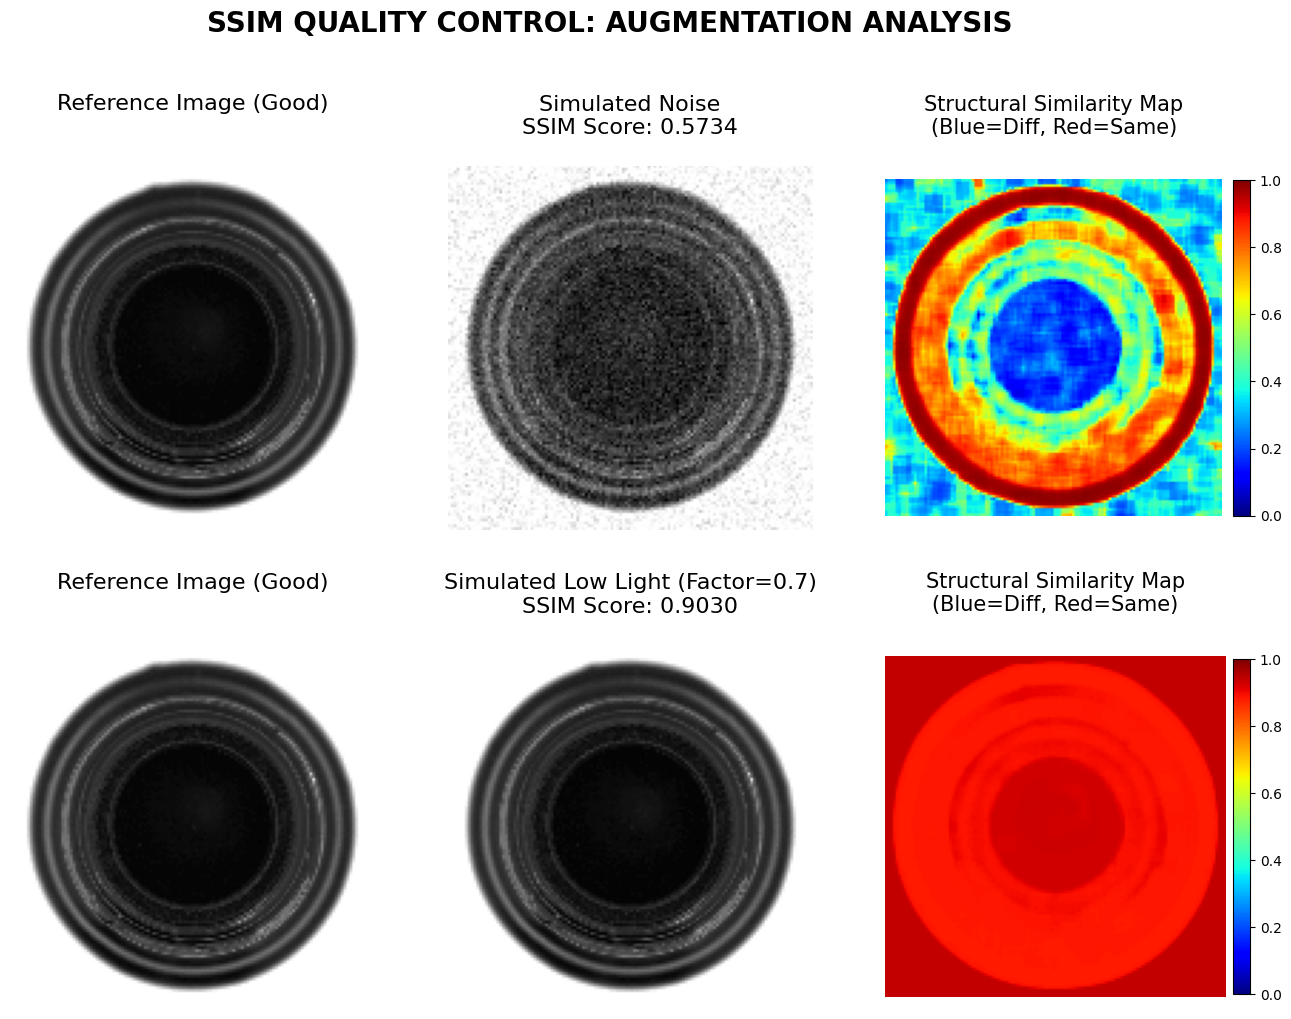


EXPERIMENTAL RESULTS SUMMARY

1. Gaussian Noise (Var=0.005) -> SSIM Score: 0.5734
2. Low Lighting   (Fact=0.70) -> SSIM Score: 0.9030


✅ CONCLUSION: PASSED.

   The augmented data retains sufficient structural integrity.
   SAFE to use these parameters for Transfer Learning (Notebook 4).


✅ BLOCK 5 COMPLETED: Quality Control Experiment finished.


In [24]:
# ==========================================================================================================================================================
# BLOCK 5: RUN EXPERIMENT & VISUALIZE RESULTS
# ==========================================================================================================================================================
# Description: Executes the augmentation scenarios, calculates SSIM scores, creates
# visual comparisons, and outputs the final pass/fail conclusion
# ==========================================================================================================================================================

print("EXECUTING SSIM QUALITY CONTROL EXPERIMENT...\n")
print("Action: Applying Augmentations, Calculating Scores & Visualizing Structural Integrity.\n")
print()


# 1. APPLY AUGMENTATIONS
# SCENARIO A: NOISY SENSOR (Simulating camera grain)
# We use a conservative variance of 0.005 to test subtle noise
noisy_sample = add_gaussian_noise(original_img, variance=0.005)

# SCENARIO B: LOW LIGHT CONDITION (Simulating bad lighting)
# We reduce brightness to 70% (factor 0.7)
dark_sample = adjust_brightness(original_img, factor=0.7)


# 2. CALCULATE SSIM QUALITY SCORES
# Compare the augmented images against the original "Gold Standard"
score_noise, diff_map_noise = calculate_ssim(original_img, noisy_sample)
score_dark, diff_map_dark = calculate_ssim(original_img, dark_sample)


# 3. VISUALIZATION
# Create a grid of 2 rows and 3 columns
fig, axes = plt.subplots(2, 3, figsize=(16, 11))
plt.suptitle("SSIM QUALITY CONTROL: AUGMENTATION ANALYSIS", fontsize=20, fontweight='bold', y=1.02)
# top=0.88:   Space for the main title
# hspace=0.4: Vertical space between rows (Space ABOVE 'Anomalous')
plt.subplots_adjust(top=0.88, hspace=0.3)

# ROW 1: NOISE ANALYSIS
# Original Image
axes[0, 0].imshow(original_img, cmap='gray')
axes[0, 0].set_title("Reference Image (Good)", fontsize=16, pad=40)
axes[0, 0].axis('off')

# Augmented Image (Noise)
axes[0, 1].imshow(noisy_sample, cmap='gray')
axes[0, 1].set_title(f"Simulated Noise\nSSIM Score: {score_noise:.4f}", fontsize=16, pad=23)
axes[0, 1].axis('off')

# Difference Map (Heatmap)
im1 = axes[0, 2].imshow(diff_map_noise, cmap='jet', vmin=0, vmax=1)
axes[0, 2].set_title("Structural Similarity Map\n(Blue=Diff, Red=Same)", fontsize=15, pad=33)
axes[0, 2].axis('off')
plt.colorbar(im1, ax=axes[0, 2], fraction=0.046, pad=0.03)

# ROW 2: LIGHTING ANALYSIS
# Original Image
axes[1, 0].imshow(original_img, cmap='gray')
axes[1, 0].set_title("Reference Image (Good)", fontsize=16, pad=40)
axes[1, 0].axis('off')

# Augmented Image (Dark)
axes[1, 1].imshow(dark_sample, cmap='gray')
axes[1, 1].set_title(f"Simulated Low Light (Factor=0.7)\nSSIM Score: {score_dark:.4f}", fontsize=16, pad=23)
axes[1, 1].axis('off')

# Difference Map (Heatmap)
im2 = axes[1, 2].imshow(diff_map_dark, cmap='jet', vmin=0, vmax=1)
axes[1, 2].set_title("Structural Similarity Map\n(Blue=Diff, Red=Same)", fontsize=15, pad=33)
axes[1, 2].axis('off')
plt.colorbar(im2, ax=axes[1, 2], fraction=0.046, pad=0.02)

plt.show()


# 4. EXPERIMENTAL CONCLUSION
print("\nEXPERIMENTAL RESULTS SUMMARY\n")
print(f"1. Gaussian Noise (Var=0.005) -> SSIM Score: {score_noise:.4f}")
print(f"2. Low Lighting   (Fact=0.70) -> SSIM Score: {score_dark:.4f}\n\n")

# Automated Decision based on Threshold (Safety Limit: 0.50)
# If SSIM drops below 0.50, the image is too destroyed to be useful for training
if score_noise > 0.50 and score_dark > 0.50:
    print("✅ CONCLUSION: PASSED.\n")
    print("   The augmented data retains sufficient structural integrity.")
    print("   SAFE to use these parameters for Transfer Learning (Notebook 4).")
else:
    print("❌ CONCLUSION: FAILED.\n")
    print("   Deformation too strong. The structural information is lost.")
    print("   ACTION REQUIRED: Reduce Noise Variance or Increase Brightness Factor.")


# FINAL VERIFICATION
print("\n\n✅ BLOCK 5 COMPLETED: Quality Control Experiment finished.")

### BLOCK 6: SENSITIVITY ANALYSIS (MULTI-VALUE TESTING)

**OBJECTIVE:**
While Block 5 provided a "snapshot" of a single scenario, this block performs a **Systematic Stress Test**. We transition from single-point validation to a comprehensive **Sensitivity Analysis**, iterating through a spectrum of degradation intensities. The goal is to mathematically determine the exact "Breaking Point" where image quality collapses.

**METHODOLOGY:**
We employ a multi-parametric approach, executing two distinct iterative loops:
1.  **Noise Sweep:** Testing variances from **0.001 (Imperceptible)** to **0.1 (Extreme Grain)**.
2.  **Luminance Sweep:** Testing brightness factors from **1.0 (Original)** down to **0.3 (Severe Underexposure)**.

**ANALYTICAL VISUALIZATION:**
The results are plotted as **Sensitivity Curves** (Parameter vs. SSIM Score).
* **The Critical Threshold (y = 0.5):** A visual marker (black dashed line) is included in the plots. This defines the **Operational Tolerance**. Any augmentation parameter that causes the curve to dip below this line is considered "unsafe" for the Transfer Learning process in Notebook 4.

EXECUTING SENSITIVITY ANALYSIS (MULTI-VALUE TESTING)...

Action: Iterating through degradation ranges to find breaking points (SSIM < 0.5)


⏳ STARTING SENSITIVITY ANALYSIS...

Testing Noise Levels:

Variance: 0.001  |  SSIM: 0.8192
Variance: 0.002  |  SSIM: 0.7206
Variance: 0.005  |  SSIM: 0.5721
Variance: 0.010  |  SSIM: 0.4563
Variance: 0.020  |  SSIM: 0.3453
Variance: 0.050  |  SSIM: 0.2227
Variance: 0.100  |  SSIM: 0.1646


Testing Brightness Levels:

Factor: 1.0  |  SSIM: 1.0000
Factor: 0.9  |  SSIM: 0.9903
Factor: 0.8  |  SSIM: 0.9599
Factor: 0.7  |  SSIM: 0.9030
Factor: 0.6  |  SSIM: 0.8185
Factor: 0.5  |  SSIM: 0.7036
Factor: 0.4  |  SSIM: 0.5619
Factor: 0.3  |  SSIM: 0.4028




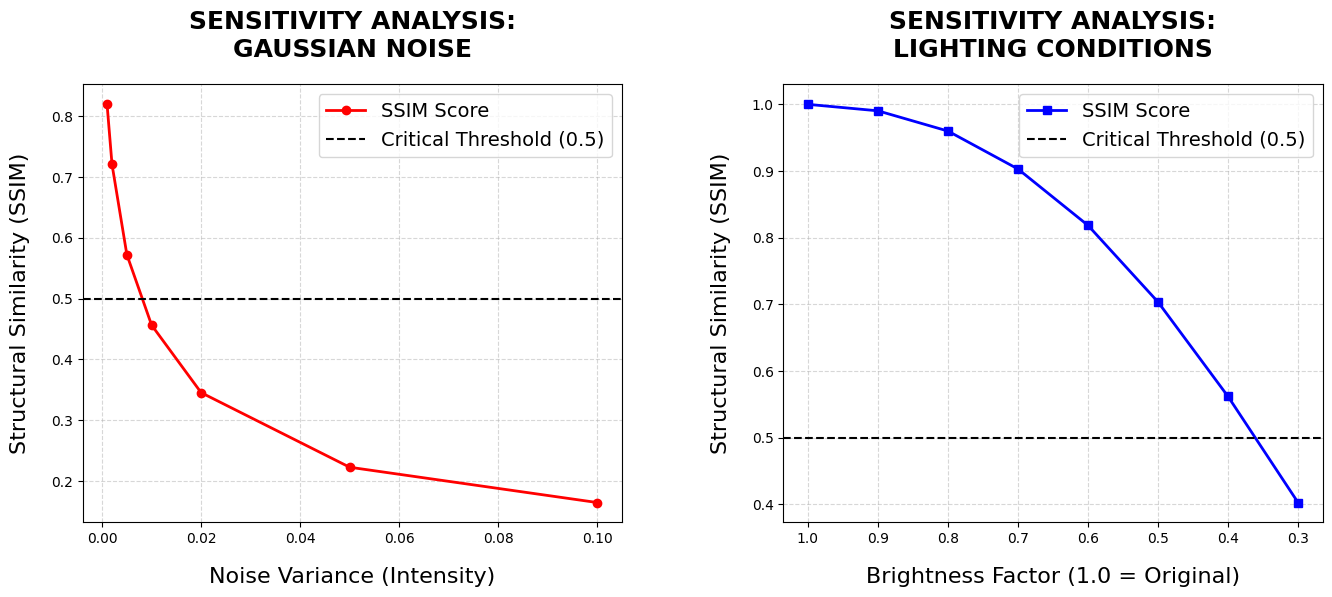



✅ BLOCK 6 COMPLETED: Sensitivity Curves generated.


In [25]:
# ==========================================================================================================================================================
# BLOCK 6: SENSITIVITY ANALYSIS (MULTI-VALUE TESTING)
# ==========================================================================================================================================================
# Description: Iterates through a range of Noise and Brightness values to create a 
# sensitivity curve. This helps identify the exact threshold where image quality 
# degrades beyond acceptable limits (SSIM < 0.5)
# ==========================================================================================================================================================

print("EXECUTING SENSITIVITY ANALYSIS (MULTI-VALUE TESTING)...\n")
print("Action: Iterating through degradation ranges to find breaking points (SSIM < 0.5)\n")
print()

print("⏳ STARTING SENSITIVITY ANALYSIS...\n")


# 1. DEFINE TEST RANGES
# We test a range of values from subtle to extreme
noise_variances = [0.001, 0.002, 0.005, 0.01, 0.02, 0.05, 0.1]
brightness_factors = [1.0, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3]

# Storage for results
ssim_noise_scores = []
ssim_bright_scores = []


# 2. EXECUTE LOOPS
# Loop A: Noise Sensitivity
print("Testing Noise Levels:\n")
for var in noise_variances:
    # Generate noisy image
    noisy_img = add_gaussian_noise(original_img, variance=var)
    # Calculate SSIM
    score, _ = calculate_ssim(original_img, noisy_img)
    # Store result
    ssim_noise_scores.append(score)
    print(f"Variance: {var:.3f}  |  SSIM: {score:.4f}")

# Loop B: Lighting Sensitivity
print("\n\nTesting Brightness Levels:\n")
for fact in brightness_factors:
    # Generate dark image
    dark_img = adjust_brightness(original_img, factor=fact)
    # Calculate SSIM
    score, _ = calculate_ssim(original_img, dark_img)
    # Store result
    ssim_bright_scores.append(score)
    print(f"Factor: {fact:.1f}  |  SSIM: {score:.4f}")
    
print("\n")


# 3. VISUALIZATION (SENSITIVITY CURVES)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Noise vs SSIM
plt.subplot(1, 2, 1)
axes[0].plot(noise_variances, ssim_noise_scores, marker='o', color='red', linewidth=2, label='SSIM Score')
axes[0].axhline(y=0.5, color='black', linestyle='--', label='Critical Threshold (0.5)')

# Formatting Plot 1 (Uppercase, Bold, Font 16, Pad 20)
axes[0].set_title("SENSITIVITY ANALYSIS:\nGAUSSIAN NOISE", fontsize=18, fontweight='bold', pad=20)
axes[0].set_xlabel("Noise Variance (Intensity)", fontsize=16, labelpad=15)
axes[0].set_ylabel("Structural Similarity (SSIM)", fontsize=16, labelpad=15)
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend(fontsize=14, loc='upper right')

# Plot 2: Brightness vs SSIM
plt.subplot(1, 2, 2)
axes[1].plot(brightness_factors, ssim_bright_scores, marker='s', color='blue', linewidth=2,label='SSIM Score')
axes[1].axhline(y=0.5, color='black', linestyle='--', label='Critical Threshold (0.5)')
# Invert because brightness goes from 1.0 -> 0.3
axes[1].invert_xaxis()

# Formatting Plot 2 (Uppercase, Bold, Font 16, Pad 20)
axes[1].set_title("SENSITIVITY ANALYSIS:\nLIGHTING CONDITIONS", fontsize=18, fontweight='bold', pad=20)
axes[1].set_xlabel("Brightness Factor (1.0 = Original)", fontsize=16, labelpad=15)
axes[1].set_ylabel("Structural Similarity (SSIM)", fontsize=16, labelpad=15)
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend(fontsize=14, loc='upper right')

# Adjust layout: 'wspace' prevents overlap, 'bottom' ensures x-labels are visible
plt.subplots_adjust(wspace=0.3, bottom=0.15)

plt.show()


# FINAL VERIFICATION
print("\n\n✅ BLOCK 6 COMPLETED: Sensitivity Curves generated.")

### BLOCK 7: EXPORT RESULTS & CONCLUSION

**OBJECTIVE:**
This final block focuses on **Data Persistence** and **Documentation**. Having completed the computational experiments, we must aggregate and serialize the findings into a structured format. This ensures the sensitivity analysis data is preserved for the written thesis tables and external graphing (e.g., in Excel/LaTeX).

**DATA MANAGEMENT STRATEGY:**
* **Consolidation:** We merge the results from the two distinct experiments (Noise and Luminance) into a single, unified Pandas DataFrame using `pd.concat`. This creates a cohesive report from the isolated tests.
* **Export (`.csv`):** The consolidated dataset is saved as `ssim_sensitivity_results.csv`.

**FINAL OUTPUT:**
A comprehensive CSV file containing three key columns:
1.  **Parameter Type:** Distinguishes between 'Gaussian Noise' and 'Brightness'.
2.  **Value:** The specific intensity level tested (Variance or Factor).
3.  **SSIM Score:** The resulting structural integrity metric.

In [26]:
# ==========================================================================================================================================================
# BLOCK 7: EXPORT RESULTS & CONCLUSION
# ==========================================================================================================================================================
# Description: Consolidation of sensitivity analysis data into a Pandas DataFrame and CSV export for thesis documentation.
# ==========================================================================================================================================================

print("FINALIZING QUALITY CONTROL PIPELINE...\n")
print("Action: Consolidating data, exporting CSV report, and generating final conclusion.\n")
print()

# DATA CONSOLIDATION
# structure of noise and brightness data into separate dataframes for alignment.
import pandas as pd

df_noise = pd.DataFrame({
    'Parameter': 'Gaussian Noise',
    'Value (Variance)': noise_variances,
    'SSIM Score': ssim_noise_scores
})

df_light = pd.DataFrame({
    'Parameter': 'Brightness',
    'Value (Factor)': brightness_factors,
    'SSIM Score': ssim_bright_scores
})

# FINAL REPORT ASSEMBLY
# combination of both dataframes into a single report.
final_report = pd.concat([df_noise, df_light], axis=0, ignore_index=True)

print("GENERATED REPORT SAMPLE\n")
print(final_report.head(14))

# CSV EXPORT
# path setup and csv file generation for the final report.
output_filename = 'ssim_sensitivity_results.csv'
output_path = os.path.join('/kaggle/working/', output_filename)

final_report.to_csv(output_path, index=False)

if os.path.exists(output_path):
    # SUCCESS NOTIFICATION
    # green background for successful csv export.
    print("\n\n✅BLOCK 7 COMPLETED. CSV file saved to: " + output_path)
else:
    # ERROR NOTIFICATION
    # red background for missing csv file.
    print("\n\n❌ BLOCK 9 FAILED: BLOCK 7 FAILED. CSV file was not created.")

FINALIZING QUALITY CONTROL PIPELINE...

Action: Consolidating data, exporting CSV report, and generating final conclusion.


GENERATED REPORT SAMPLE

         Parameter  Value (Variance)  SSIM Score  Value (Factor)
0   Gaussian Noise             0.001    0.819221             NaN
1   Gaussian Noise             0.002    0.720569             NaN
2   Gaussian Noise             0.005    0.572136             NaN
3   Gaussian Noise             0.010    0.456280             NaN
4   Gaussian Noise             0.020    0.345320             NaN
5   Gaussian Noise             0.050    0.222688             NaN
6   Gaussian Noise             0.100    0.164639             NaN
7       Brightness               NaN    1.000000             1.0
8       Brightness               NaN    0.990303             0.9
9       Brightness               NaN    0.959935             0.8
10      Brightness               NaN    0.903044             0.7
11      Brightness               NaN    0.818473             0.6
12   

In [27]:
import numpy as np

# ==========================================================================================================================================================
# BLOCK 8: GOLDEN REFERENCE EXPORT FOR DEPLOYMENT
# ==========================================================================================================================================================

# REFERENCE IMAGE SERIALIZATION
# Mathematical representation of the golden reference image saving to disk for SSIM evaluation in deployment.
np.save('golden_reference.npy', original_img)

print("\n✅ BLOCK 8 COMPLETED: Golden Reference Image exported successfully.")


✅ BLOCK 8 COMPLETED: Golden Reference Image exported successfully.
